# Classifying daily performance of US solar plants

**Data:** Sandia National Laboratories, *Extreme Weather Impacts on Utility-scale Photovoltaic Plant Performance* (one row per plant per day).

**Goal:** predict whether a plant-day has **Low**, **Medium** or **High** performance ratio (`PR`) from site, weather and O&M ticket attributes.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import MinMaxScaler
from sklearn.feature_selection import SequentialFeatureSelector
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, roc_auc_score, roc_curve

SEED = 42
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:.3f}".format)

## 1. Load

In [2]:
raw = pd.read_excel("data.xlsx", sheet_name="data")
print(raw.shape)
raw.head()

(51504, 38)


,randid,Date,NOAAClimRegion,TempZone,HumidZone,bin_PlantSize_kW,plant_age_months,active_snow_tickets,snow_bin_ticket_minutes,snow_affected_assets,snow_production_level,PR,snow_value_mm,total_daily_snow_mm,low_irradiation,cumulative_snow_mm,hurr_bin_ticket_minutes,hurr_affected_assets,hurr_production_level,HurricanePrep,HurricanePostInspection,hurricane,nearest_hurricane,wind_speed_mean,rain_value_mm,nearest_rain,storm_active_tickets,storm_bin_ticket_minutes,storm_affected_assets,storm_production_level,lightning,storm,duration_minutes_storm,nearest_storm,flood,duration_minutes_flood,nearest_flood,rain
0,C2S1,2018-04-01,West,T6,H4,large,19.000,No,NaN,NaN,Unknown,0.826,0.000,0.000,0,0.000,NaN,NaN,Unknown,No,No,0.000,354,4.483,0.000,9,No,NaN,NaN,Unknown,0,0.000,0,2420,0.000,0,2255,0.000
1,C2S1,2018-04-02,West,T6,H4,large,19.000,No,NaN,NaN,Unknown,0.788,0.000,0.000,0,0.000,NaN,NaN,Unknown,No,No,0.000,354,6.482,0.000,10,No,NaN,NaN,Unknown,0,0.000,0,2420,0.000,0,2255,0.000
2,C2S1,2018-04-03,West,T6,H4,large,19.000,No,NaN,NaN,Unknown,0.774,0.000,0.000,0,0.000,NaN,NaN,Unknown,No,No,0.000,354,5.166,0.000,11,No,NaN,NaN,Unknown,0,0.000,0,2420,0.000,0,2255,0.000
3,C2S1,2018-04-04,West,T6,H4,large,19.000,No,NaN,NaN,Unknown,0.799,0.000,0.000,0,0.000,NaN,NaN,Unknown,No,No,0.000,354,3.506,0.000,12,No,NaN,NaN,Unknown,0,0.000,0,2420,0.000,0,2255,0.000
4,C2S1,2018-04-05,West,T6,H4,large,19.000,No,NaN,NaN,Unknown,0.787,0.000,0.000,0,0.000,NaN,NaN,Unknown,No,No,0.000,354,5.429,0.000,13,No,NaN,NaN,Unknown,0,0.000,0,2420,0.000,0,2255,0.000


In [3]:
pd.DataFrame({"dtype": raw.dtypes.astype(str), "missing": raw.isna().sum(), "missing_%": raw.isna().mean() * 100, "unique": raw.nunique()})

,dtype,missing,missing_%,unique
randid,str,0,0.000,174
Date,datetime64[us],0,0.000,739
NOAAClimRegion,str,0,0.000,9
TempZone,str,0,0.000,5
HumidZone,str,0,0.000,4
bin_PlantSize_kW,str,0,0.000,3
plant_age_months,float64,148,0.287,125
active_snow_tickets,str,0,0.000,2
snow_bin_ticket_minutes,str,50714,98.466,2
snow_affected_assets,str,50714,98.466,6


## 1.1 Data quality checks

Counts of rows that look suspicious. Nothing is removed here; removal happens in 1.2.

In [4]:
pd.Series({
    "duplicate plant-days": raw.duplicated(["randid", "Date"]).sum(),
    "PR missing": raw.PR.isna().sum(),
    "PR exactly 0": (raw.PR == 0).sum(),
    "PR above 1": (raw.PR > 1).sum(),
    "plant age below 0 months": (raw.plant_age_months < 0).sum(),
    "wind speed above 50": (raw.wind_speed_mean > 50).sum(),
    "nearest_hurricane at its maximum (no event on record)": (raw.nearest_hurricane == raw.nearest_hurricane.max()).sum(),
    "nearest_storm at its maximum (no event on record)": (raw.nearest_storm == raw.nearest_storm.max()).sum(),
    "nearest_flood at its maximum (no event on record)": (raw.nearest_flood == raw.nearest_flood.max()).sum(),
}, name="rows").to_frame().assign(share=lambda t: t.rows / len(raw) * 100).rename(columns={"share": "share_%"})

,rows,share_%
duplicate plant-days,0,0.000
PR missing,1564,3.037
PR exactly 0,6343,12.316
PR above 1,457,0.887
plant age below 0 months,336,0.652
wind speed above 50,103,0.200
nearest_hurricane at its maximum (no event on record),44904,87.185
nearest_storm at its maximum (no event on record),29618,57.506
nearest_flood at its maximum (no event on record),32866,63.813


### The `PR = 0` rows

A zero on a single day can be weather. A plant reporting exactly zero for weeks or months is an offline plant or a dead data feed. The tables show how long the zero streaks are and which plants they come from.

In [5]:
ordered = raw.sort_values(["randid", "Date"])
zero = ordered.PR == 0
streak_id = (zero != zero.groupby(ordered.randid).shift()).cumsum()
streak_days = zero.groupby([ordered.randid, streak_id]).transform("size")[zero]

lengths = pd.cut(streak_days, [0, 1, 6, 29, 400], labels=["1 day", "2-6 days", "7-29 days", "30+ days"])
lengths.value_counts(sort=False).rename("zero rows").to_frame().assign(**{"share_%": lambda t: t["zero rows"] / zero.sum() * 100})

,zero rows,share_%
PR,,
1 day,820,12.928
2-6 days,583,9.191
7-29 days,933,14.709
30+ days,4007,63.172


In [6]:
plants = ordered.groupby("randid").agg(
    region=("NOAAClimRegion", "first"),
    days=("PR", "size"),
    zero_days=("PR", lambda s: (s == 0).sum()),
    median_PR=("PR", "median"),
)
plants["zero_%"] = plants.zero_days / plants.days * 100
print((plants["zero_%"] >= 90).sum(), "of", len(plants), "plants report PR = 0 on at least 90% of their days")
plants.sort_values("zero_days", ascending=False).head(15)

19 of 174 plants report PR = 0 on at least 90% of their days


,region,days,zero_days,median_PR,zero_%
randid,,,,,
C3S283,Southeast,396,396,0.000,100.000
C3S262,Northwest,396,396,0.000,100.000
C3S151,Southeast,396,306,0.000,77.273
C2S47,Northeast,278,278,0.000,100.000
C2S138,Southwest,366,269,0.000,73.497
C2S98,West,366,249,0.000,68.033
C2S49,Southwest,244,244,0.000,100.000
C2S30,West,244,244,0.000,100.000
C2S50,Southwest,244,244,0.000,100.000


## 1.2 Cleaning

Applied to a copy in memory; `data.xlsx` is never written to.

**Attributes removed:** any attribute with at least 75% of its values missing.

**Rows removed**, in this order:

| Rule | Why |
|---|---|
| `PR` missing | no class label |
| `PR` = 0 for 7 or more consecutive days at the same plant | offline plant or dead data feed, not a weather effect |
| plant age below 0 months | dated before the plant was commissioned |
| mean daily wind speed above 50 | physically impossible as a daily mean |

In [7]:
sparse = raw.columns[raw.isna().mean() >= 0.75]
(raw[sparse].isna().mean() * 100).rename("missing_%").to_frame()

,missing_%
snow_bin_ticket_minutes,98.466
snow_affected_assets,98.466
hurr_bin_ticket_minutes,99.089
hurr_affected_assets,99.089
storm_bin_ticket_minutes,98.936
storm_affected_assets,98.936


In [8]:
rules = {
    "PR missing": raw.PR.isna(),
    "PR = 0 for 7+ consecutive days": raw.index.to_series().isin(streak_days[streak_days >= 7].index),
    "plant age below 0": raw.plant_age_months < 0,
    "wind speed above 50": raw.wind_speed_mean > 50,
}

df = raw.drop(columns=sparse)
log = []
for rule, bad in rules.items():
    kept = df[~bad[df.index]]
    log.append({"rule": rule, "rows matching in raw data": bad.sum(), "rows removed": len(df) - len(kept), "rows left": len(kept)})
    df = kept

print(raw.shape, "->", df.shape)
pd.DataFrame(log).set_index("rule")

(51504, 38) -> (44665, 32)


,rows matching in raw data,rows removed,rows left
rule,,,
PR missing,1564,1564,49940
PR = 0 for 7+ consecutive days,4940,4940,45000
plant age below 0,336,242,44758
wind speed above 50,103,93,44665


Verification: the cleaned data should contain none of the removed cases, and exactly the rows that break no rule.

In [9]:
check = df.sort_values(["randid", "Date"])
still_zero = check.PR == 0
day_gap = check.groupby("randid").Date.diff().dt.days != 1
check_id = ((still_zero != still_zero.groupby(check.randid).shift()) | day_gap).cumsum()

pd.Series({
    "rows expected (raw rows breaking no rule)": (~pd.concat(rules, axis=1).any(axis=1)).sum(),
    "rows in cleaned data": len(df),
    "PR missing": df.PR.isna().sum(),
    "longest remaining PR = 0 streak (consecutive days)": still_zero.groupby([check.randid, check_id]).transform("size")[still_zero].max(),
    "plant age below 0": (df.plant_age_months < 0).sum(),
    "wind speed above 50": (df.wind_speed_mean > 50).sum(),
    "attributes with 75%+ missing": (df.isna().mean() >= 0.75).sum(),
    "plants left": df.randid.nunique(),
}, name="value").to_frame()

,value
rows expected (raw rows breaking no rule),44665
rows in cleaned data,44665
PR missing,0
longest remaining PR = 0 streak (consecutive days),6
plant age below 0,0
wind speed above 50,0
attributes with 75%+ missing,0
plants left,157


## 2. Discretizing the class (`PR`) into 3 bins

`PR` is continuous on 0 – 1.2. **Equal width** cuts that range into 3 intervals of width 0.4. **Equal frequency** is shown next to it for comparison: it puts a third of the rows in each bin, but its cut points are data-driven.

In [10]:
CLASSES = ["Low", "Medium", "High"]
EDGES = np.linspace(0, 1.2, 4)
pr = df.PR

def describe_bins(bins):
    counts = bins.value_counts(sort=False)
    return pd.DataFrame({"class": CLASSES, "interval": counts.index.astype(str), "rows": counts.values, "share_%": counts.values / len(pr) * 100})

pd.concat({
    "equal width (used)": describe_bins(pd.cut(pr, EDGES, include_lowest=True)),
    "equal frequency": describe_bins(pd.qcut(pr, 3)),
})

class        interval   rows  share_%
equal width (used) 0     Low   (-0.001, 0.4]   5411   12.115
                   1  Medium      (0.4, 0.8]  25896   57.978
                   2    High      (0.8, 1.2]  13358   29.907
equal frequency    0     Low  (-0.001, 0.73]  14889   33.335
                   1  Medium   (0.73, 0.792]  14888   33.333
                   2    High    (0.792, 1.2]  14888   33.333

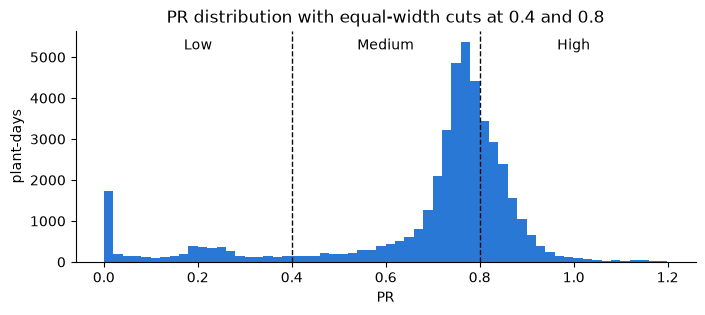

In [11]:
fig, ax = plt.subplots(figsize=(8, 3))
ax.hist(pr, bins=60, color="#2a78d6")
top = ax.get_ylim()[1]
for edge in EDGES[1:-1]:
    ax.axvline(edge, color="#0b0b0b", linestyle="--", linewidth=1)
for name, left in zip(CLASSES, EDGES):
    ax.text(left + 0.2, top * 0.92, name, ha="center")
ax.set(xlabel="PR", ylabel="plant-days", title="PR distribution with equal-width cuts at 0.4 and 0.8")
ax.spines[["top", "right"]].set_visible(False)
plt.show()

## 3. Should the numeric attributes be discretized too?

Equal-width bins (5 per attribute) on the numeric attributes. Most are so skewed that nearly every row lands in a single bin, so the attributes are kept numeric instead.

In [12]:
numeric = df.drop(columns="PR").select_dtypes("number").columns
numeric = [c for c in numeric if df[c].nunique() > 2]

def attribute_bins(col):
    counts = pd.cut(df[col], 5).value_counts(sort=False)
    return pd.DataFrame({"interval": counts.index.astype(str), "rows": counts.values, "share_%": counts.values / counts.sum() * 100})

pd.concat({c: attribute_bins(c) for c in numeric})

interval   rows  share_%
plant_age_months       0        (-0.123, 24.6]  14895   33.458
                       1          (24.6, 49.2]  15902   35.720
                       2          (49.2, 73.8]   9455   21.239
                       3          (73.8, 98.4]   3481    7.819
                       4         (98.4, 123.0]    785    1.763
snow_value_mm          0      (-0.276, 55.147]  39943   99.388
                       1     (55.147, 110.295]    160    0.398
                       2    (110.295, 165.442]     53    0.132
                       3     (165.442, 220.59]     24    0.060
                       4     (220.59, 275.737]      9    0.022
total_daily_snow_mm    0      (-0.302, 60.381]  39401   98.245
                       1     (60.381, 120.762]    452    1.127
                       2    (120.762, 181.142]    148    0.369
                       3    (181.142, 241.523]     85    0.212
                       4    (241.523, 301.904]     19    0.047
cumulative_snow_mm     0      (-3.615, 722.91]  33320   95.566
                       1    (722.91, 1445.821]    594    1.704
                       2  (1445.821, 2168.731]    441    1.265
                       3  (2168.731, 2891.641]    372    1.067
                       4  (2891.641, 3614.552]    139    0.399
nearest_hurricane      0        (-0.354, 70.8]   1921    4.301
                       1         (70.8, 141.6]   1203    2.693
                       2        (141.6, 212.4]    775    1.735
                       3        (212.4, 283.2]   1271    2.846
                       4        (283.2, 354.0]  39495   88.425
wind_speed_mean        0       (-0.049, 9.803]  37571   98.811
                       1       (9.803, 19.606]    381    1.002
                       2      (19.606, 29.409]     42    0.110
                       3      (29.409, 39.212]     17    0.045
                       4      (39.212, 49.015]     12    0.032
rain_value_mm          0      (-0.279, 55.705]  35831   99.749
                       1      (55.705, 111.41]     68    0.189
                       2     (111.41, 167.115]      9    0.025
                       3     (167.115, 222.82]     10    0.028
                       4     (222.82, 278.525]      3    0.008
nearest_rain           0        (-0.169, 33.8]  30795   68.947
                       1          (33.8, 67.6]   3031    6.786
                       2         (67.6, 101.4]   1244    2.785
                       3        (101.4, 135.2]    629    1.408
                       4        (135.2, 169.0]   8966   20.074
duration_minutes_storm 0        (-1.44, 288.0]  44646   99.957
                       1        (288.0, 576.0]      5    0.011
                       2        (576.0, 864.0]      6    0.013
                       3       (864.0, 1152.0]      3    0.007
                       4      (1152.0, 1440.0]      5    0.011
nearest_storm          0        (-2.42, 484.0]  13727   30.733
                       1        (484.0, 968.0]   3160    7.075
                       2       (968.0, 1452.0]   1458    3.264
                       3      (1452.0, 1936.0]      0    0.000
                       4      (1936.0, 2420.0]  26320   58.928
duration_minutes_flood 0        (-1.08, 216.0]  44654   99.975
                       1        (216.0, 432.0]      7    0.016
                       2        (432.0, 648.0]      2    0.004
                       3        (648.0, 864.0]      1    0.002
                       4       (864.0, 1080.0]      1    0.002
nearest_flood          0       (-2.255, 451.0]   8067   18.061
                       1        (451.0, 902.0]   4188    9.376
                       2       (902.0, 1353.0]   2772    6.206
                       3      (1353.0, 1804.0]    338    0.757
                       4      (1804.0, 2255.0]  29300   65.599

## 4. Preprocessing

In [13]:
y = pd.cut(df.PR, EDGES, labels=False, include_lowest=True).rename("class")
X = df.drop(columns=["randid", "Date", "PR"]).assign(month=df.Date.dt.month)

categorical = X.select_dtypes(exclude="number").columns
X[categorical] = X[categorical].fillna("None").apply(lambda s: s.astype("category").cat.codes)

print(X.shape)

(44665, 30)


## 5. Stratified train / test split

In [14]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, stratify=y, random_state=SEED)

split = pd.DataFrame({"train": y_train.value_counts(sort=False), "test": y_test.value_counts(sort=False)}).sort_index()
split.index = CLASSES
split.assign(**{"train_%": split.train / split.train.sum() * 100, "test_%": split.test / split.test.sum() * 100})

,train,test,train_%,test_%
Low,3788,1623,12.116,12.112
Medium,18127,7769,57.979,57.978
High,9350,4008,29.906,29.910


In [15]:
imputer = SimpleImputer(strategy="median").fit(X_train)
scaler = MinMaxScaler().fit(imputer.transform(X_train))

def prepare(data):
    return pd.DataFrame(scaler.transform(imputer.transform(data)), columns=data.columns, index=data.index)

X_train, X_test = prepare(X_train), prepare(X_test)

## 6. Attribute selection: 4 Weka algorithms + 1 manual set + all attributes as a baseline

| Set | Weka attribute evaluator | Weka search method | How it works |
|---|---|---|---|
| InfoGain | `InfoGainAttributeEval` | `Ranker` (numToSelect = 10) | H(class) − H(class given attribute) |
| GainRatio | `GainRatioAttributeEval` | `Ranker` (numToSelect = 10) | InfoGain / H(attribute) |
| CFS | `CfsSubsetEval` (locallyPredictive = False) | `GreedyStepwise` (forward) | subset merit: high correlation with the class, low correlation between attributes |
| Wrapper | `WrapperSubsetEval` (decision tree in place of J48, 5 folds) | `GreedyStepwise` (forward) | adds the attribute that most improves cross-validated accuracy, stops when nothing improves |
| Manual | – | – | chosen by us |
| All | – | – | baseline, no selection |

As in Weka, the three entropy-based evaluators first discretize numeric attributes with the supervised Fayyad & Irani MDL method (Weka's `Discretize` filter). The cut points are learned on the training set and are used for attribute selection only.

In [16]:
def entropy(counts):
    p = counts / counts.sum(axis=-1, keepdims=True)
    return -(p * np.log2(p, out=np.zeros_like(p), where=p > 0)).sum(axis=-1)

def mdl_cut_points(x, y):
    order = np.argsort(x)
    x, onehot = x[order], np.eye(len(CLASSES))[y[order]]

    def split(lo, hi):
        n = hi - lo
        total = onehot[lo:hi].sum(axis=0)
        left = onehot[lo:hi].cumsum(axis=0)[:-1]
        right = total - left
        n_left = np.arange(1, n)
        h_left, h_right = entropy(left), entropy(right)
        h_split = (n_left * h_left + (n - n_left) * h_right) / n
        h_split[x[lo + 1:hi] == x[lo:hi - 1]] = np.inf
        i = h_split.argmin()
        if np.isinf(h_split[i]):
            return []
        h = entropy(total)
        k, k_left, k_right = (total > 0).sum(), (left[i] > 0).sum(), (right[i] > 0).sum()
        delta = np.log2(3 ** k - 2) - (k * h - k_left * h_left[i] - k_right * h_right[i])
        if h - h_split[i] <= (np.log2(n - 1) + delta) / n:
            return []
        cut = lo + i + 1
        return split(lo, cut) + [(x[cut - 1] + x[cut]) / 2] + split(cut, hi)

    return split(0, len(x))

numeric = X.columns.difference(categorical)
cut_points = {c: mdl_cut_points(X_train[c].to_numpy(), y_train.to_numpy()) for c in numeric}

D_train = X_train.copy()
for c in numeric:
    D_train[c] = np.digitize(X_train[c], cut_points[c])

pd.Series({c: len(cuts) + 1 for c, cuts in cut_points.items()}, name="MDL bins").sort_values(ascending=False).to_frame().T

,plant_age_months,nearest_hurricane,cumulative_snow_mm,nearest_flood,nearest_storm,month,nearest_rain,wind_speed_mean,rain_value_mm,snow_value_mm,total_daily_snow_mm,hurricane,low_irradiation,duration_minutes_flood,rain,flood,lightning,duration_minutes_storm,storm
MDL bins,25,17,16,15,13,9,9,6,4,3,3,2,2,2,2,1,1,1,1


In [17]:
def info_gain(a, b):
    table = pd.crosstab(a, b).to_numpy()
    return entropy(table.sum(axis=0)) - (table.sum(axis=1) / table.sum()) @ entropy(table)

def gain_ratio(a, b):
    return info_gain(a, b) / (entropy(a.value_counts().to_numpy()) or 1)

def symmetrical_uncertainty(a, b):
    return 2 * info_gain(a, b) / ((entropy(a.value_counts().to_numpy()) + entropy(b.value_counts().to_numpy())) or 1)

def cfs(D, y):
    class_corr = D.apply(symmetrical_uncertainty, b=y)
    attr_corr = D.apply(lambda a: D.apply(symmetrical_uncertainty, b=a))

    def merit(cols):
        corr = attr_corr.loc[cols, cols].to_numpy()
        between = corr.sum() - np.trace(corr)
        return class_corr[cols].sum() / np.sqrt(len(cols) + between)

    chosen, best = [], 0
    while True:
        candidates = {c: merit(chosen + [c]) for c in D.columns.difference(chosen)}
        winner = max(candidates, key=candidates.get)
        if candidates[winner] <= best:
            return chosen
        chosen, best = chosen + [winner], candidates[winner]

K = 10
ranking = pd.DataFrame({
    "InfoGain": D_train.apply(info_gain, b=y_train),
    "GainRatio": D_train.apply(gain_ratio, b=y_train),
})
ranking.sort_values("InfoGain", ascending=False)

,InfoGain,GainRatio
NOAAClimRegion,0.157,0.071
month,0.117,0.038
plant_age_months,0.111,0.027
TempZone,0.109,0.069
nearest_rain,0.082,0.029
low_irradiation,0.079,0.094
total_daily_snow_mm,0.048,0.143
nearest_flood,0.047,0.023
nearest_hurricane,0.043,0.042
cumulative_snow_mm,0.041,0.043


In [18]:
tree = DecisionTreeClassifier(criterion="entropy", min_samples_leaf=20, random_state=SEED)
wrapper = SequentialFeatureSelector(tree, n_features_to_select="auto", tol=0, cv=5, n_jobs=-1).fit(X_train, y_train)

attribute_sets = {
    "InfoGain": list(ranking.InfoGain.nlargest(K).index),
    "GainRatio": list(ranking.GainRatio.nlargest(K).index),
    "CFS": cfs(D_train, y_train),
    "Wrapper": list(wrapper.get_feature_names_out()),
    "Manual": [
        "month", "low_irradiation", "snow_value_mm", "cumulative_snow_mm", "rain_value_mm",
        "wind_speed_mean", "plant_age_months", "bin_PlantSize_kW", "NOAAClimRegion", "TempZone",
    ],
    "All": list(X.columns),
}

pd.DataFrame({name: pd.Series(cols) for name, cols in attribute_sets.items() if name != "All"}).fillna("")

,InfoGain,GainRatio,CFS,Wrapper,Manual
0,NOAAClimRegion,snow_value_mm,NOAAClimRegion,NOAAClimRegion,month
1,month,total_daily_snow_mm,low_irradiation,TempZone,low_irradiation
2,plant_age_months,duration_minutes_flood,total_daily_snow_mm,HumidZone,snow_value_mm
3,TempZone,low_irradiation,month,bin_PlantSize_kW,cumulative_snow_mm
4,nearest_rain,NOAAClimRegion,TempZone,plant_age_months,rain_value_mm
5,low_irradiation,TempZone,,active_snow_tickets,wind_speed_mean
6,total_daily_snow_mm,active_snow_tickets,,snow_value_mm,plant_age_months
7,nearest_flood,snow_production_level,,total_daily_snow_mm,bin_PlantSize_kW
8,nearest_hurricane,cumulative_snow_mm,,low_irradiation,NOAAClimRegion
9,cumulative_snow_mm,nearest_hurricane,,cumulative_snow_mm,TempZone


## 7. Train and test 6 attribute sets × 4 classifiers = 24 models

5 attribute selections × 4 classifiers = 20 models, plus 4 baseline models on all attributes.

| Classifier | Weka equivalent |
|---|---|
| DecisionTree | `J48` (closest match: scikit-learn grows a CART tree, here with the entropy criterion) |
| RandomForest | `RandomForest` |
| NaiveBayes | `NaiveBayes` |
| Logistic | `Logistic` |

In [19]:
classifiers = {
    "DecisionTree": DecisionTreeClassifier(criterion="entropy", min_samples_leaf=20, random_state=SEED),
    "RandomForest": RandomForestClassifier(n_estimators=200, n_jobs=-1, random_state=SEED),
    "NaiveBayes": GaussianNB(),
    "Logistic": LogisticRegression(max_iter=1000),
}

support = np.bincount(y_test)
weights = support / support.sum()

rows, probabilities = [], {}
for set_name, cols in attribute_sets.items():
    for clf_name, clf in classifiers.items():
        prob = clf.fit(X_train[cols], y_train).predict_proba(X_test[cols])
        cm = confusion_matrix(y_test, prob.argmax(axis=1))
        tp = np.diag(cm)
        fp = cm.sum(axis=0) - tp
        tp_rate = tp / support
        fp_rate = fp / (support.sum() - support)
        probabilities[set_name, clf_name] = prob
        rows.append({
            "attributes": set_name,
            "classifier": clf_name,
            "accuracy": tp.sum() / support.sum(),
            **{f"TP_{c}": r for c, r in zip(CLASSES, tp_rate)},
            **{f"FP_{c}": r for c, r in zip(CLASSES, fp_rate)},
            "TP_rate": tp_rate @ weights,
            "FP_rate": fp_rate @ weights,
            "AUC": roc_auc_score(y_test, prob, multi_class="ovr", average="weighted"),
        })

results = pd.DataFrame(rows)
results.sort_values("AUC", ascending=False).reset_index(drop=True)

,attributes,classifier,accuracy,TP_Low,TP_Medium,TP_High,FP_Low,FP_Medium,FP_High,TP_rate,FP_rate,AUC
0,All,RandomForest,0.784,0.699,0.844,0.702,0.043,0.245,0.108,0.784,0.179,0.902
1,Wrapper,RandomForest,0.780,0.691,0.838,0.704,0.043,0.245,0.113,0.780,0.181,0.899
2,InfoGain,RandomForest,0.766,0.648,0.833,0.684,0.046,0.257,0.123,0.766,0.191,0.889
3,All,DecisionTree,0.758,0.634,0.833,0.664,0.048,0.273,0.121,0.758,0.200,0.884
4,Wrapper,DecisionTree,0.751,0.620,0.828,0.656,0.050,0.281,0.124,0.751,0.206,0.883
5,Manual,RandomForest,0.752,0.654,0.816,0.668,0.050,0.268,0.130,0.752,0.200,0.879
6,InfoGain,DecisionTree,0.739,0.595,0.823,0.633,0.050,0.301,0.130,0.739,0.220,0.875
7,Manual,DecisionTree,0.731,0.611,0.822,0.602,0.055,0.320,0.123,0.731,0.229,0.863
8,CFS,DecisionTree,0.676,0.525,0.801,0.493,0.061,0.421,0.134,0.676,0.292,0.809
9,CFS,RandomForest,0.675,0.480,0.805,0.501,0.059,0.425,0.136,0.675,0.294,0.808


## 8. Performance comparison

`TP_<class>` / `FP_<class>` are the per-class rates. `TP_rate`, `FP_rate` and `AUC` are averages weighted by class size, as in Weka's "Weighted Avg." row (weighted TP rate equals accuracy).

In [20]:
for metric in ["accuracy", "TP_Low", "TP_Medium", "TP_High", "FP_rate", "AUC"]:
    table = results.pivot(index="attributes", columns="classifier", values=metric).loc[list(attribute_sets), list(classifiers)]
    display(table.style.format("{:.3f}").background_gradient(cmap="Blues", axis=None).set_caption(metric))

classifier,DecisionTree,RandomForest,NaiveBayes,Logistic
attributes,,,,
InfoGain,0.739,0.766,0.614,0.609
GainRatio,0.641,0.645,0.352,0.594
CFS,0.676,0.675,0.589,0.597
Wrapper,0.751,0.780,0.585,0.609
Manual,0.731,0.752,0.594,0.594
All,0.758,0.784,0.311,0.616


classifier,DecisionTree,RandomForest,NaiveBayes,Logistic
attributes,,,,
InfoGain,0.595,0.648,0.275,0.401
GainRatio,0.494,0.501,0.214,0.420
CFS,0.525,0.480,0.195,0.405
Wrapper,0.620,0.691,0.259,0.425
Manual,0.611,0.654,0.212,0.376
All,0.634,0.699,0.206,0.419


classifier,DecisionTree,RandomForest,NaiveBayes,Logistic
attributes,,,,
InfoGain,0.823,0.833,0.783,0.891
GainRatio,0.864,0.860,0.099,0.929
CFS,0.801,0.805,0.754,0.913
Wrapper,0.828,0.838,0.779,0.890
Manual,0.822,0.816,0.800,0.902
All,0.833,0.844,0.001,0.886


classifier,DecisionTree,RandomForest,NaiveBayes,Logistic
attributes,,,,
InfoGain,0.633,0.684,0.423,0.144
GainRatio,0.269,0.286,0.898,0.015
CFS,0.493,0.501,0.428,0.061
Wrapper,0.656,0.704,0.341,0.137
Manual,0.602,0.668,0.348,0.085
All,0.664,0.702,0.954,0.172


classifier,DecisionTree,RandomForest,NaiveBayes,Logistic
attributes,,,,
InfoGain,0.220,0.191,0.346,0.435
GainRatio,0.377,0.369,0.296,0.478
CFS,0.292,0.294,0.359,0.465
Wrapper,0.206,0.181,0.379,0.433
Manual,0.229,0.200,0.375,0.459
All,0.200,0.179,0.284,0.425


classifier,DecisionTree,RandomForest,NaiveBayes,Logistic
attributes,,,,
InfoGain,0.875,0.889,0.725,0.706
GainRatio,0.735,0.738,0.662,0.684
CFS,0.809,0.808,0.729,0.685
Wrapper,0.883,0.899,0.698,0.712
Manual,0.863,0.879,0.707,0.692
All,0.884,0.902,0.689,0.717


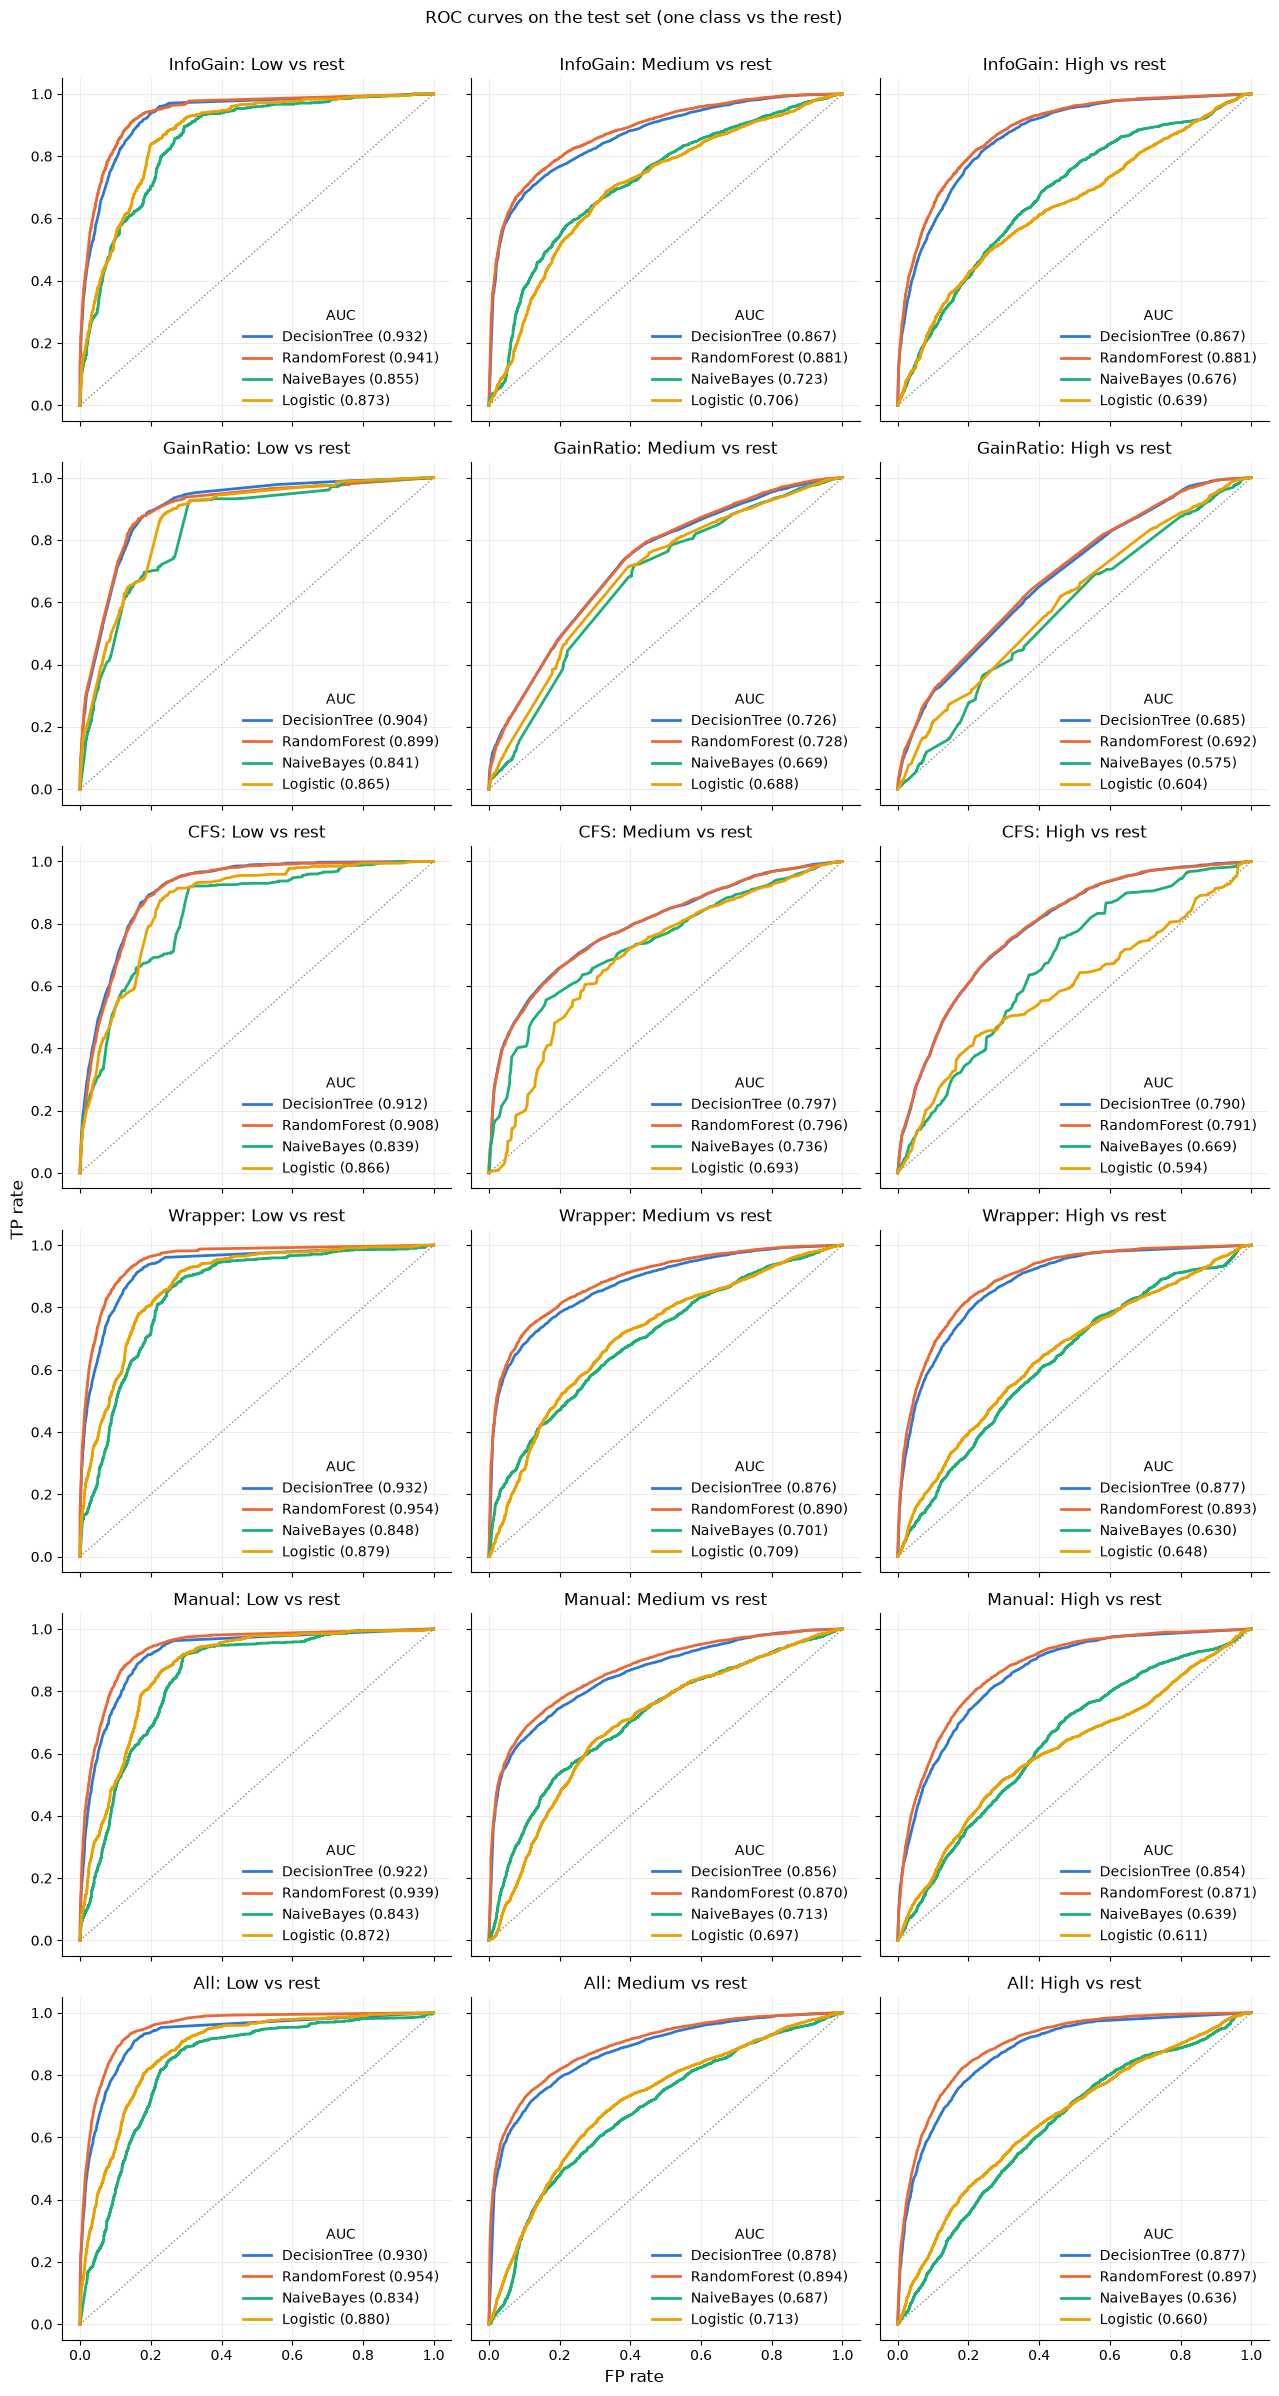

In [21]:
colors = dict(zip(classifiers, ["#2a78d6", "#eb6834", "#1baf7a", "#eda100"]))

fig, axes = plt.subplots(len(attribute_sets), 3, figsize=(13, 24), sharex=True, sharey=True)
for row, set_name in zip(axes, attribute_sets):
    for i, (ax, class_name) in enumerate(zip(row, CLASSES)):
        ax.plot([0, 1], [0, 1], color="#898781", linestyle=":", linewidth=1)
        for clf_name in classifiers:
            prob = probabilities[set_name, clf_name][:, i]
            fpr, tpr, _ = roc_curve(y_test == i, prob)
            ax.plot(fpr, tpr, color=colors[clf_name], linewidth=2, label=f"{clf_name} ({roc_auc_score(y_test == i, prob):.3f})")
        ax.set_title(f"{set_name}: {class_name} vs rest")
        ax.legend(title="AUC", loc="lower right", frameon=False)
        ax.spines[["top", "right"]].set_visible(False)
        ax.grid(color="#e6e5e0", linewidth=0.5)
fig.supxlabel("FP rate")
fig.supylabel("TP rate")
fig.suptitle("ROC curves on the test set (one class vs the rest)", y=1)
plt.tight_layout()
plt.show()

## 9. Best model

In [22]:
best = results.sort_values("AUC", ascending=False).iloc[0]
best

attributes             All
classifier    RandomForest
accuracy             0.784
TP_Low               0.699
TP_Medium            0.844
TP_High              0.702
FP_Low               0.043
FP_Medium            0.245
FP_High              0.108
TP_rate              0.784
FP_rate              0.179
AUC                  0.902
Name: 21, dtype: object

In [23]:
prob = probabilities[best.attributes, best.classifier]
pd.DataFrame(
    confusion_matrix(y_test, prob.argmax(axis=1)),
    index=[f"actual {c}" for c in CLASSES],
    columns=[f"predicted {c}" for c in CLASSES],
)

,predicted Low,predicted Medium,predicted High
actual Low,1134,349,140
actual Medium,339,6555,875
actual High,165,1030,2813


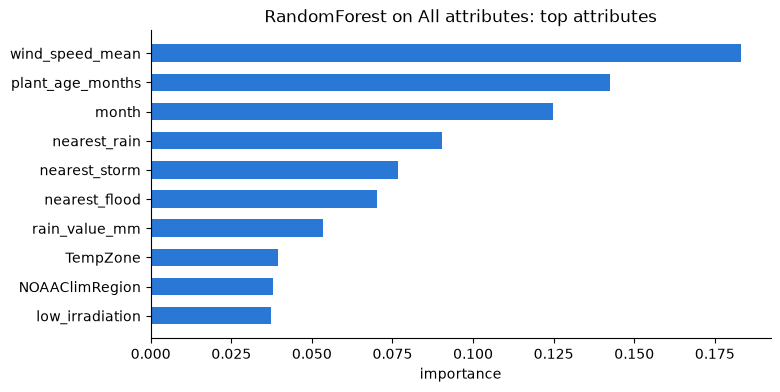

In [24]:
cols = attribute_sets[best.attributes]
model = classifiers[best.classifier].fit(X_train[cols], y_train)
importance = pd.Series(model.feature_importances_, index=cols).nlargest(10).sort_values()

fig, ax = plt.subplots(figsize=(8, 4))
ax.barh(importance.index, importance.values, color="#2a78d6", height=0.6)
ax.set(xlabel="importance", title=f"{best.classifier} on {best.attributes} attributes: top attributes")
ax.spines[["top", "right"]].set_visible(False)
plt.show()